# Chapter 5: What the Model Becomes Inside an Agent

The model chooses an action, but the tool determines what that action does. Changing the tool can therefore change the assembled agent while the chooser stays fixed. The same applies to memory, observations, and recurrence: the model is one factor in a stochastic system, not the whole system boundary.

This notebook composes a small chooser matrix with a tool matrix and follows the resulting state distribution over repeated transitions. Beside that kernel experiment, it compares two reliability constructions with identical marginal step success. One has independent step outcomes; the other has a single shared good-or-bad condition. Their disagreement makes a practical point: multiplying average step rates is not justified merely because the averages look reassuring.

**Outcome:** Compose a chooser and tool kernel, then separate marginal from trajectory reliability.

- Inspect the declared input contract
- Predict the hand-checkable case
- Run the shared computation
- Change the critical assumption
- Apply the method to the transfer data

**Guided route:** Run the worked calculation, inspect its figure, change the stated assumption, and try the transfer case. Read the explanations beside each result before opening the answers.

**Deeper route:** First read the mathematics and canonical equation reference. Audit the input contract, predict the changed result, then inspect the shared chapter implementation and solve the questions independently. Both routes use the same calculations and preserve the equations.

## Technical Requirements

Python 3.11 or later and the packages in `requirements.txt` at the top of the repository. No API key, model account or network call is used by this experiment.

Prior knowledge:

- Python lists and dictionaries
- The mapped chapter and its notation

## The question and its mathematics

Let C(i,a) be the chooser probability of action a in state i, and T(a,j) the tool probability of next state j after that action. The composed kernel is K(i,j)=sum_a C(i,a)T(a,j). Its rows sum to one when both factors are normalized. A row-vector state distribution evolves as mu_(t+1)=mu_t K.

This finite factorization deliberately omits state-dependent tool effects beyond the declared action encoding. To model them, enlarge the state/action representation rather than silently crediting the chooser with tool behavior. The changed tool kernel leaves C fixed, so any distributional difference is attributable to that controlled factor change inside this construction.

For reliability, independent equal-probability steps give P(all n succeed)=p^n. A shared condition that makes every step succeed together with probability p gives P(all n succeed)=p. Both have marginal step success p. The general chain rule is the product of conditional probabilities P(S_t|S_1,...,S_(t-1)); supplied marginals are not those conditionals.

The conditional_success vector is therefore a separate input. Its product describes its own declared trajectory law and need not have the same length or dependence structure as the plotted equal-step cases. None of these constructed distributions predicts a real agent without corresponding evidence.

The assembly comparison makes the remaining system factors explicit. O maps state to observed context; M maps observed context through the declared memory transform; R applies the retrieval transform; C is the same frozen chooser; T supplies the tool effect. The assembly kernel is O M R C T. Every row-stochastic product remains row stochastic. These finite maps are a construction, not a representation learned from documents. The state and context encoding must contain whatever history matters for the intended Markov boundary.

## A calculation you can run

Supply normalized chooser rows, normalized tool rows, and an initial state distribution. The chooser's action dimension must match the tool's row count, and the tool's next-state dimension must match the chooser's state count. The function multiplies the factors, then propagates the initial distribution for the declared number of steps.

The state-zero occupancy chart shows recurrence under the composite kernel. The two reliability charts use transition count on the horizontal axis and all-step success probability on the vertical axis. They are separate constructions, not estimates from the occupancy curve. Change the tool matrix while keeping the chooser fixed, then compare terminal state distributions. Use the explicit conditional vector to check the chain rule independently by hand.

Compare five assemblies: complete context, blurred memory, blurred retrieval, blurred observation, and a single-transition controller. Their declared resource allowances match in the default case. A blurred map sends either context to the same equal mixture, erasing its distinction before the fixed chooser acts. The recurrence comparison changes transition count while reserving the same allowance; it does not claim equal consumed work. Read assembly_budgets_matched and assembly_depths_matched before attributing an observed difference to one factor. The transfer case deliberately breaks budget equality.

The next cell finds the repository root and imports the same computation used by the chapter skill. It does not change your system Python.

In [1]:
from pathlib import Path
import sys, json
LAB_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").is_file() and (p / "src" / "math_ai_agents").is_dir()), None)
if LAB_ROOT is None:
    raise RuntimeError("Open this notebook from a clone of the math-ai-agents repository.")
sys.path.insert(0, str(LAB_ROOT / "src"))
from math_ai_agents.core import analyze, report_text
from math_ai_agents.plotting import figure_svg
from IPython.display import SVG, display


Set the declared inputs below. These are constructed teaching values, not measurements from a production agent. Change a value only after predicting what it should change.

In [2]:
chapter = 5
inputs = {'step_success': 0.99,
 'steps': 100,
 'conditional_success': [0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99],
 'chooser': [[0.8, 0.2], [0.3, 0.7]],
 'tool': [[0.9, 0.1], [0.2, 0.8]],
 'initial': [1, 0],
 'assemblies': [{'name': 'complete',
                 'budget': 100,
                 'steps': 10,
                 'observation': [[1, 0], [0, 1]],
                 'memory': [[1, 0], [0, 1]],
                 'retrieval': [[1, 0], [0, 1]],
                 'tool': [[0.9, 0.1], [0.2, 0.8]]},
                {'name': 'memory blurred',
                 'budget': 100,
                 'steps': 10,
                 'observation': [[1, 0], [0, 1]],
                 'memory': [[0.5, 0.5], [0.5, 0.5]],
                 'retrieval': [[1, 0], [0, 1]],
                 'tool': [[0.9, 0.1], [0.2, 0.8]]},
                {'name': 'retrieval blurred',
                 'budget': 100,
                 'steps': 10,
                 'observation': [[1, 0], [0, 1]],
                 'memory': [[1, 0], [0, 1]],
                 'retrieval': [[0.5, 0.5], [0.5, 0.5]],
                 'tool': [[0.9, 0.1], [0.2, 0.8]]},
                {'name': 'observation blurred',
                 'budget': 100,
                 'steps': 10,
                 'observation': [[0.5, 0.5], [0.5, 0.5]],
                 'memory': [[1, 0], [0, 1]],
                 'retrieval': [[1, 0], [0, 1]],
                 'tool': [[0.9, 0.1], [0.2, 0.8]]},
                {'name': 'single transition',
                 'budget': 100,
                 'steps': 1,
                 'observation': [[1, 0], [0, 1]],
                 'memory': [[1, 0], [0, 1]],
                 'retrieval': [[1, 0], [0, 1]],
                 'tool': [[0.9, 0.1], [0.2, 0.8]]}]}
report = analyze(chapter, inputs)
# This input was explicitly taken from the teaching fixture.
report['evidence_kind'] = 'constructed teaching example'
print(report_text(report))

Chapter 5: composite-kernel
What system does a frozen chooser become when its surrounding kernel changes?
Evidence: constructed teaching example

Calculated quantities:
{
  "assemblies": [
    {
      "assembly": "complete",
      "budget": 100.0,
      "steps": 10,
      "kernel": [
        [
          0.76,
          0.24
        ],
        [
          0.41,
          0.59
        ]
      ],
      "terminal_distribution": [
        0.6307794162,
        0.3692205838
      ]
    },
    {
      "assembly": "memory blurred",
      "budget": 100.0,
      "steps": 10,
      "kernel": [
        [
          0.585,
          0.415
        ],
        [
          0.585,
          0.415
        ]
      ],
      "terminal_distribution": [
        0.585,
        0.415
      ]
    },
    {
      "assembly": "retrieval blurred",
      "budget": 100.0,
      "steps": 10,
      "kernel": [
        [
          0.585,
          0.415
        ],
        [
          0.585,
          0.415
        ]
     

With p=0.99 and n=100, independent all-step success is about 0.366. Under the shared condition, all-step success is 0.99. The per-step marginals are identical. That contrast rules out treating a marginal success rate as enough information to determine long-run completion.

The default composed first row is [0.76,0.24]: action-zero contribution is 0.8 times [0.9,0.1], and action-one contribution is 0.2 times [0.2,0.8]. In the changed case this row becomes [0.50,0.50] because only the tool factor changes. The frozen chooser now participates in a different recurrent system, even though its own probabilities are unchanged.

The plot below uses the calculated quantities. Read each panel's units before comparing its values.

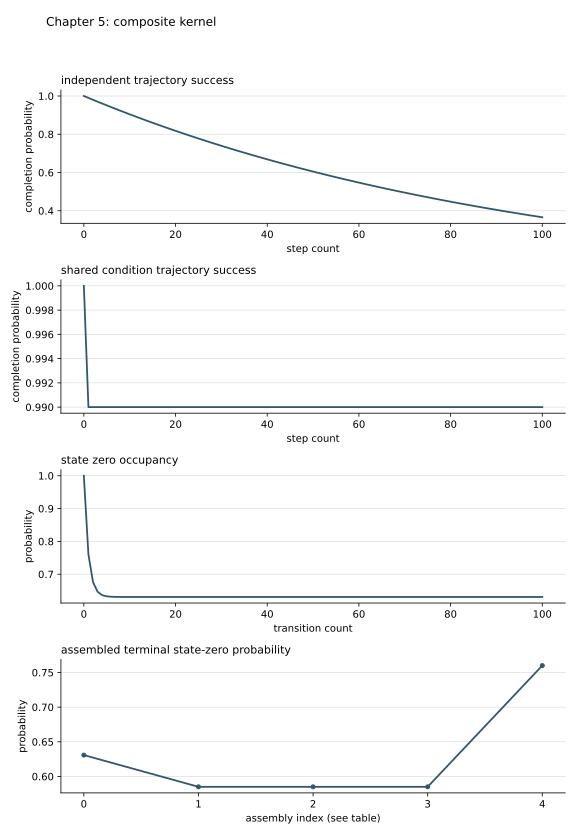

In [3]:
display(SVG(figure_svg(report)))

**Figure 5.L1:** Calculated chapter experiment. Each panel labels its input and output units; interpret it under the assumptions printed in the report.

## Change the assumption

A product of marginal rates can be exact in an independent construction and seriously wrong under shared failures. It can also be pessimistic when the workflow detects, retries, or recovers from errors. This notebook does not include recovery, so its all-step event should not be renamed authorized confirmed terminal completion.

A composite kernel can also fail through a state boundary that omits information needed for the next transition. If memory version or tool state affects outcomes, but neither appears in the current state, the supplied kernel may not describe a Markov process. Adding more recurrence iterations will not repair that omission.

The changed case is a controlled mechanism experiment, not a fitted explanation of empirical behavior. Real ablations need matched budgets, observations, and task populations. Preserve those conditions before claiming that one surrounding component accounts for measured agent improvement.

The optional assembly table supplies observation, memory and retrieval ablations alongside recurrence. A changed terminal distribution identifies the consequence of the stipulated map within this construction. It does not show that a real memory or retrieval mechanism has the same effect. Different budgets or transition depths change the comparison contract and must be reported; the transfer table exposes a mismatched budget.

Chapter 5: composite-kernel
What system does a frozen chooser become when its surrounding kernel changes?
Evidence: constructed changed-assumption example

Calculated quantities:
{
  "assemblies": [
    {
      "assembly": "complete",
      "budget": 100.0,
      "steps": 10,
      "kernel": [
        [
          0.5,
          0.5
        ],
        [
          0.25,
          0.75
        ]
      ],
      "terminal_distribution": [
        0.3333339691,
        0.6666660309
      ]
    },
    {
      "assembly": "memory blurred",
      "budget": 100.0,
      "steps": 10,
      "kernel": [
        [
          0.375,
          0.625
        ],
        [
          0.375,
          0.625
        ]
      ],
      "terminal_distribution": [
        0.375,
        0.625
      ]
    },
    {
      "assembly": "retrieval blurred",
      "budget": 100.0,
      "steps": 10,
      "kernel": [
        [
          0.375,
          0.625
        ],
        [
          0.375,
          0.625
       

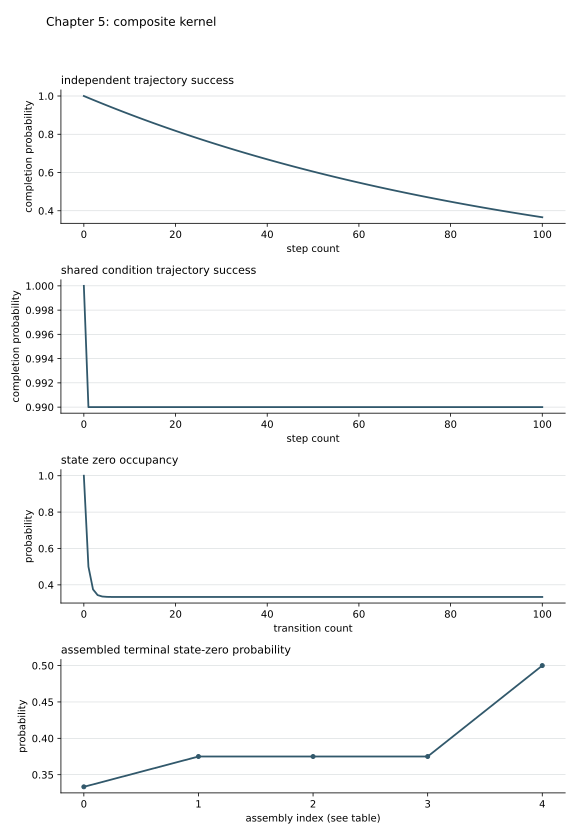

In [4]:
changed_inputs = {'step_success': 0.99,
 'steps': 100,
 'conditional_success': [0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99,
                         0.99],
 'chooser': [[0.8, 0.2], [0.3, 0.7]],
 'tool': [[0.6, 0.4], [0.1, 0.9]],
 'initial': [1, 0],
 'assemblies': [{'name': 'complete',
                 'budget': 100,
                 'steps': 10,
                 'observation': [[1, 0], [0, 1]],
                 'memory': [[1, 0], [0, 1]],
                 'retrieval': [[1, 0], [0, 1]],
                 'tool': [[0.6, 0.4], [0.1, 0.9]]},
                {'name': 'memory blurred',
                 'budget': 100,
                 'steps': 10,
                 'observation': [[1, 0], [0, 1]],
                 'memory': [[0.5, 0.5], [0.5, 0.5]],
                 'retrieval': [[1, 0], [0, 1]],
                 'tool': [[0.6, 0.4], [0.1, 0.9]]},
                {'name': 'retrieval blurred',
                 'budget': 100,
                 'steps': 10,
                 'observation': [[1, 0], [0, 1]],
                 'memory': [[1, 0], [0, 1]],
                 'retrieval': [[0.5, 0.5], [0.5, 0.5]],
                 'tool': [[0.6, 0.4], [0.1, 0.9]]},
                {'name': 'observation blurred',
                 'budget': 100,
                 'steps': 10,
                 'observation': [[0.5, 0.5], [0.5, 0.5]],
                 'memory': [[1, 0], [0, 1]],
                 'retrieval': [[1, 0], [0, 1]],
                 'tool': [[0.6, 0.4], [0.1, 0.9]]},
                {'name': 'single transition',
                 'budget': 100,
                 'steps': 1,
                 'observation': [[1, 0], [0, 1]],
                 'memory': [[1, 0], [0, 1]],
                 'retrieval': [[1, 0], [0, 1]],
                 'tool': [[0.6, 0.4], [0.1, 0.9]]}]}
changed = analyze(chapter, changed_inputs)
changed['evidence_kind'] = 'constructed changed-assumption example'
print(report_text(changed))
display(SVG(figure_svg(changed)))

**Figure 5.L2:** The changed-assumption result. Compare the printed quantities and the stated assumptions with the first run. A different input need not imply a causal effect in a deployed agent.

## Try a new case

The transfer case uses three conditional probabilities 0.9,0.8,0.7. Their chain-rule product is 0.504. The equal marginal independent construction gives 0.9^3=0.729, while the shared construction gives 0.9. They answer different distributional questions.

For a local controller, specify the complete state sufficient for one transition, then identify the chooser and effect boundary. If data provide only run-level completions, route them to the evaluation method instead of manufacturing a step kernel. If they provide uncertain tool acknowledgements, use an effect trace. The right reliability calculation follows the available evidence, not the presence of a convenient average.

In [5]:
transfer_inputs = {'step_success': 0.9,
 'steps': 3,
 'conditional_success': [0.9, 0.8, 0.7],
 'chooser': [[1, 0], [0, 1]],
 'tool': [[0.7, 0.3], [0.4, 0.6]],
 'initial': [0.5, 0.5],
 'assemblies': [{'name': 'complete',
                 'budget': 100,
                 'steps': 10,
                 'observation': [[1, 0], [0, 1]],
                 'memory': [[1, 0], [0, 1]],
                 'retrieval': [[1, 0], [0, 1]],
                 'tool': [[0.7, 0.3], [0.4, 0.6]]},
                {'name': 'memory blurred',
                 'budget': 120,
                 'steps': 10,
                 'observation': [[1, 0], [0, 1]],
                 'memory': [[0.5, 0.5], [0.5, 0.5]],
                 'retrieval': [[1, 0], [0, 1]],
                 'tool': [[0.7, 0.3], [0.4, 0.6]]},
                {'name': 'retrieval blurred',
                 'budget': 100,
                 'steps': 10,
                 'observation': [[1, 0], [0, 1]],
                 'memory': [[1, 0], [0, 1]],
                 'retrieval': [[0.5, 0.5], [0.5, 0.5]],
                 'tool': [[0.7, 0.3], [0.4, 0.6]]},
                {'name': 'observation blurred',
                 'budget': 100,
                 'steps': 10,
                 'observation': [[0.5, 0.5], [0.5, 0.5]],
                 'memory': [[1, 0], [0, 1]],
                 'retrieval': [[1, 0], [0, 1]],
                 'tool': [[0.7, 0.3], [0.4, 0.6]]},
                {'name': 'single transition',
                 'budget': 100,
                 'steps': 1,
                 'observation': [[1, 0], [0, 1]],
                 'memory': [[1, 0], [0, 1]],
                 'retrieval': [[1, 0], [0, 1]],
                 'tool': [[0.7, 0.3], [0.4, 0.6]]}]}
transfer = analyze(chapter, transfer_inputs)
transfer['evidence_kind'] = 'constructed transfer example'
print(report_text(transfer))

Chapter 5: composite-kernel
What system does a frozen chooser become when its surrounding kernel changes?
Evidence: constructed transfer example

Calculated quantities:
{
  "assemblies": [
    {
      "assembly": "complete",
      "budget": 100.0,
      "steps": 10,
      "kernel": [
        [
          0.7,
          0.3
        ],
        [
          0.4,
          0.6
        ]
      ],
      "terminal_distribution": [
        0.5714281496,
        0.4285718503
      ]
    },
    {
      "assembly": "memory blurred",
      "budget": 120.0,
      "steps": 10,
      "kernel": [
        [
          0.55,
          0.45
        ],
        [
          0.55,
          0.45
        ]
      ],
      "terminal_distribution": [
        0.55,
        0.45
      ]
    },
    {
      "assembly": "retrieval blurred",
      "budget": 100.0,
      "steps": 10,
      "kernel": [
        [
          0.55,
          0.45
        ],
        [
          0.55,
          0.45
        ]
      ],
      "ter

## Apply the method to your inputs

The example file below has the exact input shape the method accepts. Copy it to a new file, replace its values, then point `reader_file` at your copy. Run the cell again. Supplied inputs retain their stated provenance; the program cannot establish that they are representative observations.

- **step_success:** Marginal equal-step probability in [0,1] for separate constructed reliability cases.
- **steps:** Positive integer transition count up to 1000.
- **conditional_success:** List of probabilities conditioned on all previous steps succeeding, one per step; its length must equal steps.
- **chooser:** State by action row-stochastic matrix.
- **tool:** Action by next-state row-stochastic matrix.
- **initial:** Normalized state distribution matching the composed kernel.
- **assemblies:** Optional rows with name,budget,steps,observation,memory,retrieval,tool. Context maps are square stochastic matrices in the declared context encoding. Chooser stays fixed. Resource allowances must share units; actual consumed work is not measured.

In [6]:
reader_file = LAB_ROOT / 'data/examples/ch05.json'
reader_inputs = json.loads(reader_file.read_text())
reader_report = analyze(chapter, reader_inputs)
print(report_text(reader_report))

Chapter 5: composite-kernel
What system does a frozen chooser become when its surrounding kernel changes?
Evidence: supplied local inputs; provenance not independently verified

Calculated quantities:
{
  "assemblies": [
    {
      "assembly": "complete",
      "budget": 100.0,
      "steps": 10,
      "kernel": [
        [
          0.7,
          0.3
        ],
        [
          0.4,
          0.6
        ]
      ],
      "terminal_distribution": [
        0.5714281496,
        0.4285718503
      ]
    },
    {
      "assembly": "memory blurred",
      "budget": 120.0,
      "steps": 10,
      "kernel": [
        [
          0.55,
          0.45
        ],
        [
          0.55,
          0.45
        ]
      ],
      "terminal_distribution": [
        0.55,
        0.45
      ]
    },
    {
      "assembly": "retrieval blurred",
      "budget": 100.0,
      "steps": 10,
      "kernel": [
        [
          0.55,
          0.45
        ],
        [
          0.55,
          0.

## Questions

1. Compute the default first kernel row.

2. Why can an independent-step model and a shared good-or-bad-condition model both have step marginals p?

3. Compute the transfer conditional product.

Answers: [separate solutions](../solutions/ch05.md). Try the calculation before opening them.

## Summary

An assembled agent has a composite transition kernel. A fixed chooser can behave differently when tool effects change, and recurrence exposes those differences over time. Trajectory reliability depends on joint or conditional structure: equal marginal rates support neither independence nor a universal ceiling. Keep kernel composition, independent construction, shared-condition construction, and chain-rule inputs distinct. The notebook calculates each honestly, while leaving recovery and empirical calibration outside its implemented boundary. The optional factor table holds the chooser fixed while inspecting context transformations and recurrence, and reports allowance and depth comparability explicitly.

Limits of this experiment:

- This is a local calculation under declared inputs, not an empirical claim about a deployed agent.
- Read the returned assumptions and limitations before applying the numerical result.

The matching skill is [`skills/05-composite-kernel`](../skills/05-composite-kernel/). It uses this notebook's computation and input contract.

## Equations from the chapter

These are the unchanged display equations and their explanations from the canonical chapter. They are a reference for the experiment, not a claim that every equation is numerically implemented by this one method.

### Equation un-numbered display 1

![Equation un-numbered display 1](../assets/math/788eb3973bb881ecf8ff.svg)



LaTeX source, preserved for inspection:

```latex
0.90(0.85)+0.10(0.10)=0.775.
```

### Equation 5.1

![Equation 5.1](../assets/math/5f46914d9ff9a53d8e15.svg)

Equation (5.1) says the agent's real state is larger than its current prompt, bundling context with retained memory, the world, and the remaining budget.

The state at time $t$ is the four listed coordinates held together: the context, the memory, the world, and the budget.

LaTeX source, preserved for inspection:

```latex
x_t=(c_t,m_t,w_t,b_t).
\tag{5.1}
```

### Equation un-numbered display 3

![Equation un-numbered display 3](../assets/math/58eccb7e6e81e54929b0.svg)



LaTeX source, preserved for inspection:

```latex
\pi_\theta(z,a\mid x)=K_\theta(z\mid c)\operatorname{dec}(a\mid z,c).
```

### Equation 5.2

![Equation 5.2](../assets/math/d730604202b83b1f70fe.svg)

Equation (5.2) defines every coordinate of the next state and separates a controlled transition from the policy that selects proposals.

For a fixed proposal, draw the permission outcome, next world and observation, then the internal update, and average that normalized transition over the model and decoder's proposal law.

LaTeX source, preserved for inspection:

```latex
\begin{aligned}
P_{\mathrm{env}}(x'\mid x,u)
 &=\sum_{g,o}\operatorname{Grant}(g\mid x,u)\\
 &\quad\cdot \operatorname{Env}(w',o\mid x,u,g)\\
 &\quad\cdot \operatorname{Upd}(c',m',b'\mid x,u,g,w',o),\\[3pt]
P_\theta(x'\mid x)
 &=\sum_u\pi_\theta(u\mid x)P_{\mathrm{env}}(x'\mid x,u).
\end{aligned}
\tag{5.2}
```

### Equation 5.3

![Equation 5.3](../assets/math/570697d8140dd69c230d.svg)

Equation (5.3) states when merging detailed states preserves the controlled process relevant to action.

From either detailed state, an allowed action must send equal probability into every abstract class.

LaTeX source, preserved for inspection:

```latex
\sum_{y:\kappa(y)=\bar y}P(y\mid x_1,a)
=
\sum_{y:\kappa(y)=\bar y}P(y\mid x_2,a).
\tag{5.3}
```

### Equation 5.4

![Equation 5.4](../assets/math/94b9a9d7210adada496e.svg)

Equation (5.4) measures how much a tool's observation actually reduces uncertainty about the thing the agent needs to know.

Subtract the uncertainty remaining about $Y$ after seeing the observation from the uncertainty before it; what remains is what the observation told you.

LaTeX source, preserved for inspection:

```latex
I(Y;O)=H(Y)-H(Y\mid O).
\tag{5.4}
```

### Equation 5.5

![Equation 5.5](../assets/math/4bb12830ba698a772a97.svg)

Equation (5.5) says a whole run's probability is a product of one-step probabilities, so recurrence multiplies rather than adds.

Start from the initial state and multiply the one-step transition probabilities along the run.

LaTeX source, preserved for inspection:

```latex
\Pr(x_{0:T})=\Pr(x_0)\prod_{t=0}^{T-1}P(x_{t+1}\mid x_t).
\tag{5.5}
```